# Replay Trajectory

First, connect to your robot.  

In [1]:
from reachy2_sdk import ReachySDK

reachy = ReachySDK(host='192.168.10.172')  # Replace with the actual IP

Local API version (1.0.21) is different from the robot's API version (1.0.19).
Some features may not work properly.
Please update the reachy2_core image on the robot to ensure compatibility, or downgrade your local reachy2_sdk package.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.



In [3]:
reachy.turn_on()

True

### 🦾 Example 2: Play a sine wave on r_arm elbow

In [4]:
import time
import math

# Parameters
frequency = 0.5  # Hz, so one full movement every 2 seconds
duration = 5     # seconds
update_rate = 0.01  # 100Hz

start_time = time.time()

while time.time() - start_time < duration:
    t = time.time() - start_time
    angle = -25 + 25 * math.sin(2 * math.pi * frequency * t)  # Range: 0° to -50°
    reachy.r_arm.elbow.pitch.goal_position = angle
    reachy.send_goal_positions()
    time.sleep(update_rate)

### Recording a trajectory

In [15]:
reachy.r_arm.turn_off_smoothly()

True

In [11]:
recorded_joints = [
    reachy.r_arm._shoulder.pitch,
    reachy.r_arm._shoulder.roll,
    reachy.r_arm._elbow.yaw,
    reachy.r_arm._elbow.pitch,
    reachy.r_arm._wrist.roll,
    reachy.r_arm._wrist.pitch,
    reachy.r_arm._wrist.yaw,
]

sampling_frequency = 100    # in Hz
record_duration = 5         # in sec.

import time

trajectories = []

start = time.time()
while (time.time() - start) < record_duration:
    # Here we get the present position for all recorded joints
    current_point = [joint.present_position for joint in recorded_joints]
    # Add this point to the already recorded trajectories
    trajectories.append(current_point)

    time.sleep(1 / sampling_frequency)

### Moving and Recording

In [6]:
import time
import math

# Parameters
frequency = 0.5             # Hz, so one full movement every 2 seconds
duration = 5                # seconds
update_rate = 0.01          # 100Hz
recorded_joints = [
    reachy.r_arm._shoulder.pitch,
    reachy.r_arm._shoulder.roll,
    reachy.r_arm._elbow.yaw,
    reachy.r_arm._elbow.pitch,
    reachy.r_arm._wrist.roll,
    reachy.r_arm._wrist.pitch,
    reachy.r_arm._wrist.yaw,
]
trajectories = []

start_time = time.time()

while time.time() - start_time < duration:
    t = time.time() - start_time
    angle = -25 + 25 * math.sin(2 * math.pi * frequency * t)  # Range: 0° to -50°
    reachy.r_arm.elbow.pitch.goal_position = angle
    reachy.send_goal_positions()

    current_point = [joint.present_position for joint in recorded_joints]
    trajectories.append(current_point)  

    time.sleep(update_rate)

### Visualize your recordings

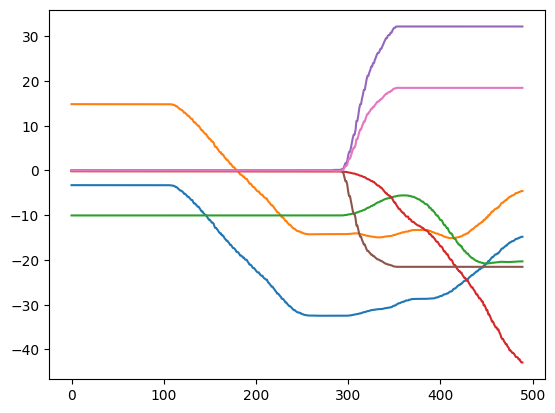

In [12]:
import numpy as np

traj_array = np.array(trajectories)

from matplotlib import pyplot as plt

plt.figure()
plt.plot(trajectories)

### Replay a recorded trajectory

##### Put the arm in the right position

In [13]:
import numpy as np

# Set all joints stiff
reachy.r_arm.turn_on()

# First trajectory point (already ordered correctly)
target = list(trajectories[0])

print("Replaying trajectory to target:", target)

# Execute motion
reachy.r_arm.goto(target, duration=3.0, wait=True)

Replaying trajectory to target: [-3.2856373139120696, 14.818628159097925, -10.053300797828408, -0.18061716222606017, -0.027865007364056643, -0.006769206886555243, -0.009513620584264672]


id: 225

##### Replay the trajectory

In [14]:
import time

for joints_positions in trajectories:
    for joint, pos in zip(recorded_joints, joints_positions):
        joint.goal_position = pos
    reachy.send_goal_positions(check_positions=False)
    time.sleep(1 / sampling_frequency)